## Document Forgery Detection: Machine Learning Classification Report

### Overview

This notebook trains and evaluates a Random Forest model for forged-document detection using features produced by `forged_document_detector.py`.
The report emphasizes stakeholder-ready evidence for banking use cases:
- **Accuracy and class-level quality** (precision, recall, F1-score)
- **Confusion matrix** on both hold-out and `input_docs` generated data
- **Risk-oriented metrics** like false positive/negative rates
- **Model explainability** via top forensic indicators


In [1]:
import json
import os
from pathlib import Path
import joblib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_fscore_support,
    roc_auc_score,
)

from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Load datasets generated from `input_docs`
TRAIN_DATASET_PATH = "ml_training_data.csv"
INPUT_DOCS_DATASET_PATH = "ml_test_data.csv"

if not Path(TRAIN_DATASET_PATH).exists():
    raise FileNotFoundError(f"Missing required dataset: {TRAIN_DATASET_PATH}")

df_train_raw = pd.read_csv(TRAIN_DATASET_PATH)
print("Training dataset shape:", df_train_raw.shape)
display(df_train_raw.head())

print("Training label distribution:")
print(df_train_raw["Label"].value_counts())
assert df_train_raw["Label"].nunique() == 2, (
    "Dataset contains only one class; forgery detection requires genuine + forged examples."
)
if Path(INPUT_DOCS_DATASET_PATH).exists():
    df_input_docs = pd.read_csv(INPUT_DOCS_DATASET_PATH)
    print("Input-docs evaluation dataset shape:", df_input_docs.shape)
    print("Input-docs label distribution:")
    print(df_input_docs["Label"].value_counts())
else:
    df_input_docs = None
    print("No ml_test_data.csv found. Input-docs evaluation will be skipped.")


Training dataset shape: (300, 24)


,Document_ID,Label,Country_Code,Char_Count,NER_Detected_Count,NER_Completeness_Ratio,H_Mean,H_STD,W_Mean,W_STD,...,Grad_Mean,Grad_STD,Ink_Density_Mean,Geo_Anomaly_Ratio,Ink_Anomaly_Ratio,BG_Mean,BG_STD,OCR_Box_Anomalies_Count,BG_Anomaly_Line_Count,Clustered_Regions_Count
0,alb_id_00.jpg,0,ALB,1031,0,0.0,14.871969,18.104747,10.681862,16.236242,...,1081.513725,805.213918,0.395999,0.088264,0.029098,201.798470,21.507284,3,0,135
1,alb_id_00_fake_6_25.jpg,1,ALB,926,0,0.0,15.379050,19.206223,11.402808,17.750270,...,1052.257494,847.928616,0.400173,0.091793,0.031317,201.770948,21.277130,2,0,126
2,alb_id_01.jpg,0,ALB,1058,0,0.0,15.126654,18.177476,10.912098,16.734184,...,1076.812163,804.949704,0.395686,0.095463,0.025520,201.710142,21.788141,3,0,146
3,alb_id_01_fake_6_56.jpg,1,ALB,1063,0,0.0,15.146754,18.255094,10.976482,16.199846,...,1059.275508,809.192322,0.393883,0.089370,0.027281,201.669039,21.578188,3,0,144
4,alb_id_01_fake_6_61.jpg,1,ALB,1137,0,0.0,14.646438,16.848277,10.488127,14.759523,...,1056.630225,783.919841,0.392323,0.087071,0.025506,201.589883,21.536542,3,0,163


Training label distribution:
Label
1    160
0    140
Name: count, dtype: int64
Input-docs evaluation dataset shape: (300, 24)
Input-docs label distribution:
Label
1    160
0    140
Name: count, dtype: int64


In [3]:
# Feature / Target Split
DROP_COLUMNS = ["Document_ID", "Label"]
X_raw = df_train_raw.drop(columns=DROP_COLUMNS, errors="ignore")
y = df_train_raw["Label"].astype(int)

# Handle non-numeric features (e.g., Country_Code='LVA')
categorical_cols = X_raw.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical columns detected:", categorical_cols if categorical_cols else "None")
X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=False)
print("Encoded feature count:", X.shape[1])
print("Sample encoded feature columns:", X.columns[:10].tolist())


Categorical columns detected: ['Country_Code']
Encoded feature count: 24
Sample encoded feature columns: ['Char_Count', 'NER_Detected_Count', 'NER_Completeness_Ratio', 'H_Mean', 'H_STD', 'W_Mean', 'W_STD', 'AR_Mean', 'AR_STD', 'Ink_Mean']


### Train/Test Split (70:30 Ratio)

In [4]:
# 70:30 hold-out split for unbiased validation
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 210
Testing samples: 90


### Baseline Model

In [5]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_preds = dummy.predict(X_test)

print("=== BASELINE (Most Frequent Class) ===")
print(f"Accuracy: {accuracy_score(y_test, dummy_preds):.4f}")
print(classification_report(y_test, dummy_preds, target_names=["Genuine", "Forged"], zero_division=0))


=== BASELINE (Most Frequent Class) ===
Accuracy: 0.5333
              precision    recall  f1-score   support

     Genuine       0.00      0.00      0.00        42
      Forged       0.53      1.00      0.70        48

    accuracy                           0.53        90
   macro avg       0.27      0.50      0.35        90
weighted avg       0.28      0.53      0.37        90



### Random Forest Classifier Training

In [6]:
# Train Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=350,
    max_depth=12,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
)
rf_model.fit(X_train, y_train)
print("Random Forest training complete.")



Random Forest training complete.


In [7]:
from sklearn import metrics


def evaluate_classifier(model, X_eval, y_eval, dataset_name="Dataset"):
    preds = model.predict(X_eval)
    probs = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else None

    precision, recall, f1, _ = precision_recall_fscore_support(
       y_eval, 
       preds, 
       average='binary', 
       zero_division=0,
       )  
      
    metrics = {
        "dataset": dataset_name,
        "accuracy": float(accuracy_score(y_eval, preds)),
        "balanced_accuracy": float(balanced_accuracy_score(y_eval, preds)),
        "precision" : float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "mcc": float(matthews_corrcoef(y_eval, preds)),
        "roc_auc": float(roc_auc_score(y_eval, probs)) if probs is not None else None,
        "classification_report" : classification_report(
            y_eval, 
            preds, 
            target_names=["Genuine", "Forged"],
            output_dict=True,
            zero_division=0,
            )
     }
        
    tn, fp, fn, tp = confusion_matrix(y_eval, preds).ravel()
    metrics.update(
        {
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0,
            "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) > 0 else 0.0,
        }
    )

    print(f"=== RANDOM FOREST RESULTS ({dataset_name}) ===")
    print(f"Accuracy:           {metrics['accuracy']:.4f}")
    print(f"Balanced Accuracy:  {metrics['balanced_accuracy']:.4f}")
    print(f"Precision:          {metrics['precision']:.4f}")
    print(f"Recall:             {metrics['recall']:.4f}")
    print(f"F1-Score:           {metrics['f1_score']:.4f}")
    print(f"MCC:                {metrics['mcc']:.4f}")
    if metrics["roc_auc"] is not None:
        print(f"ROC AUC:        {metrics['roc_auc']:.4f}")
    print(f"FPR / FNR:         {metrics['false_positive_rate']:.4f} / {metrics['false_negative_rate']:.4f}")
    print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(classification_report(y_eval, preds, target_names=["Genuine", "Forged"], zero_division=0))

    return preds, metrics

y_pred_holdout, holdout_metrics = evaluate_classifier(rf_model, X_test, y_test, dataset_name="Hold-out Test")

    

=== RANDOM FOREST RESULTS (Hold-out Test) ===
Accuracy:           0.7444
Balanced Accuracy:  0.7396
Precision:          0.7358
Recall:             0.8125
F1-Score:           0.7723
MCC:                0.4858
ROC AUC:        0.8199
FPR / FNR:         0.3333 / 0.1875
Confusion Matrix: TN=28, FP=14, FN=9, TP=39
              precision    recall  f1-score   support

     Genuine       0.76      0.67      0.71        42
      Forged       0.74      0.81      0.77        48

    accuracy                           0.74        90
   macro avg       0.75      0.74      0.74        90
weighted avg       0.75      0.74      0.74        90



#### Save the Trained Model

This avoids having to retrain the model every time you want to make a prediction.

In [8]:
MODEL_DIR = "trained_models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "forged_document_rf_model.pkl")
joblib.dump(rf_model, model_path)
print(f"Trained model saved to: {model_path}")

Trained model saved to: trained_models\forged_document_rf_model.pkl


In [9]:
# Save feature column order for consistent inference
feature_columns_path = os.path.join(MODEL_DIR, "feature_columns.pkl")
joblib.dump(list(X.columns), feature_columns_path)

print(f"Feature column order saved to: {feature_columns_path}")
metrics_path = os.path.join(MODEL_DIR, "training_metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(holdout_metrics, f, indent=2)
print(f"Hold-out metrics saved to: {metrics_path}")

Feature column order saved to: trained_models\feature_columns.pkl
Hold-out metrics saved to: trained_models\training_metrics.json


### Key Results and Risk Signals for Banking Stakeholders

The next sections provide model evidence relevant to financial institutions:
- How many genuine documents may be wrongly blocked (**False Positives**)
- How many forged documents may pass undetected (**False Negatives**)
- Which forensic signals contribute most to automated screening decisions

### Confusion Matrix (Hold-out Test Set)

The Confusion Matrix visually represents the model's performance on the testing set, detailing true positives, true negatives, and classification errors.

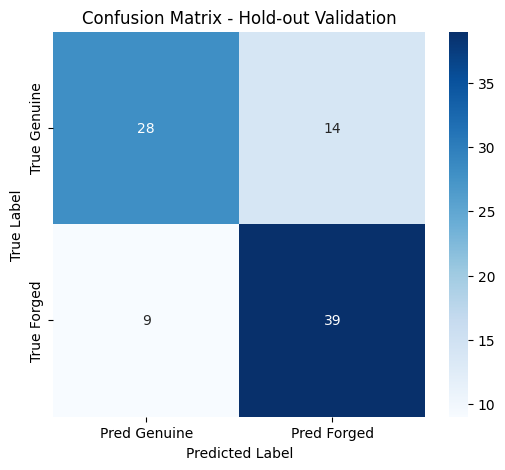

In [10]:
cm = confusion_matrix(y_test, y_pred_holdout)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Genuine", "Pred Forged"],
    yticklabels=["True Genuine", "True Forged"],
)
plt.title("Confusion Matrix - Hold-out Validation")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


=== RANDOM FOREST RESULTS (Input Docs) ===
Accuracy:           0.9233
Balanced Accuracy:  0.9219
Precision:          0.9152
Recall:             0.9437
F1-Score:           0.9292
MCC:                0.8461
ROC AUC:        0.9757
FPR / FNR:         0.1000 / 0.0563
Confusion Matrix: TN=126, FP=14, FN=9, TP=151
              precision    recall  f1-score   support

     Genuine       0.93      0.90      0.92       140
      Forged       0.92      0.94      0.93       160

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



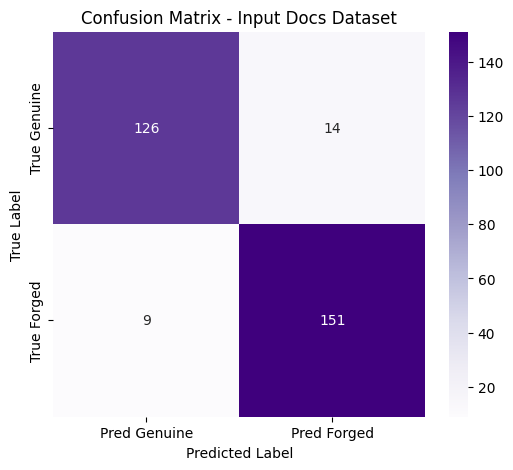

Updated metrics saved to: trained_models\training_metrics.json


In [11]:
# Evaluation on input_docs-derived dataset (ml_test_data.csv)
input_docs_metrics = None
if df_input_docs is not None:
    X_input_raw = df_input_docs.drop(columns=DROP_COLUMNS, errors="ignore")
    y_input_docs = df_input_docs["Label"].astype(int)

    # Apply same one-hot logic and align columns to training matrix
    X_input_docs = pd.get_dummies(X_input_raw, columns=categorical_cols, drop_first=False)
    X_input_docs = X_input_docs.reindex(columns=X.columns, fill_value=0)
    y_pred_input_docs, input_docs_metrics = evaluate_classifier(
        rf_model, 
        X_input_docs, 
        y_input_docs, 
        dataset_name="Input Docs"
    )

    cm_input = confusion_matrix(y_input_docs, y_pred_input_docs)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_input,
        annot=True,
        fmt="d",
        cmap="Purples",
        xticklabels=["Pred Genuine", "Pred Forged"],
        yticklabels=["True Genuine", "True Forged"],
    )

    plt.title("Confusion Matrix - Input Docs Dataset")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    # Update persisted metrics with input_docs evaluation
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump({"holdout": holdout_metrics, "input_docs": input_docs_metrics}, f, indent=2)
        print(f"Updated metrics saved to: {metrics_path}")
else:
    print("Input-docs evaluation skipped (ml_test_data.csv not found).")

#### Feature Importance

This chart highlights the most influential forensic features used by the Random Forest model. These indicators can guide compliance teams when prioritizing manual review and fraud controls.

In [12]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(15)


Ink_Density_Mean           0.088526
W_Mean                     0.084036
Geo_Anomaly_Ratio          0.082688
H_STD                      0.080018
H_Mean                     0.069239
AR_STD                     0.068856
W_STD                      0.064411
Clustered_Regions_Count    0.052627
AR_Mean                    0.052056
Char_Count                 0.051722
Grad_STD                   0.051130
BG_STD                     0.044552
BG_Mean                    0.043610
Ink_Mean                   0.042912
Ink_STD                    0.040385
dtype: float64

In [13]:
results = X_test.copy()
results["True_Label"] = y_test.values
results["Predicted_Label"] = y_pred_holdout

errors = results[results["True_Label"] != results["Predicted_Label"]]
print("Misclassified hold-out samples:", len(errors))

errors.head()


Misclassified hold-out samples: 23


,Char_Count,NER_Detected_Count,NER_Completeness_Ratio,H_Mean,H_STD,W_Mean,W_STD,AR_Mean,AR_STD,Ink_Mean,...,BG_Mean,BG_STD,OCR_Box_Anomalies_Count,BG_Anomaly_Line_Count,Clustered_Regions_Count,Country_Code_ALB,Country_Code_LVA,Country_Code_SVK,True_Label,Predicted_Label
270,322,0,0.0,14.552795,15.881901,16.922360,27.824152,1.030434,0.728031,151.480720,...,179.773759,15.693892,2,0,91,False,False,True,1,0
41,860,0,0.0,15.088372,18.524380,10.291860,16.911182,0.691260,0.438356,200.938873,...,201.945737,21.811728,2,0,106,True,False,False,0,1
280,328,0,0.0,14.829268,16.881983,16.625000,27.365128,1.032478,0.739537,149.073028,...,179.371085,16.352239,2,0,80,False,False,True,1,0
248,332,0,0.0,13.409639,13.397569,14.825301,25.279514,1.009834,0.734367,161.026714,...,183.743202,15.168085,2,0,103,False,False,True,1,0
168,414,0,0.0,19.371981,16.553289,21.466184,31.538223,1.125246,0.847257,155.112757,...,228.116347,20.661648,2,0,55,False,True,False,0,1


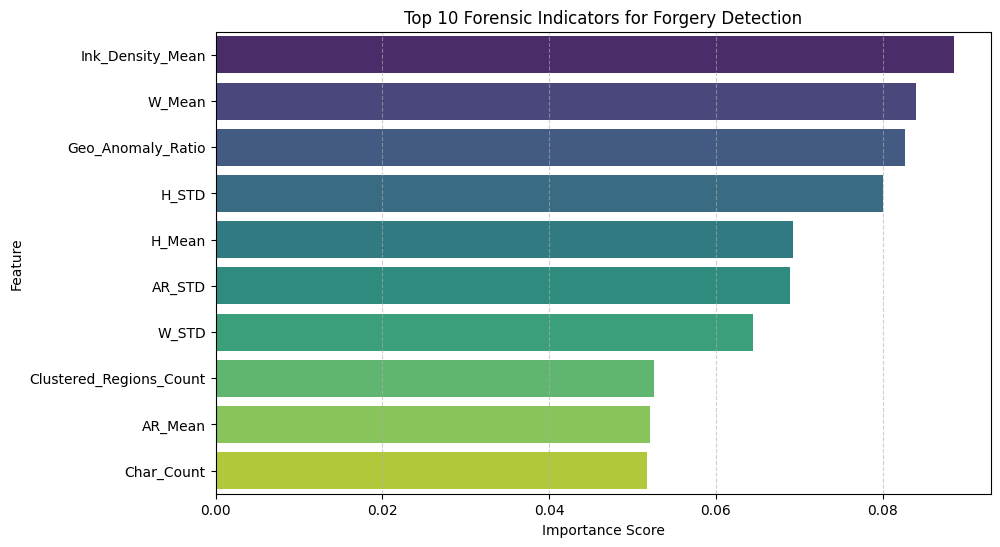

In [14]:
# Top 10 forensic indicator
top_features = importances.nlargest(10)
plt.figure(figsize=(10, 6))
top_features = importances.nlargest(10)
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title('Top 10 Forensic Indicators for Forgery Detection')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [15]:
# Executive-ready summary table
summary_rows = [
  {
    "Dataset": "Hold-out Test",
    "Accuracy": holdout_metrics["accuracy"],
    "Balanced Accuracy": holdout_metrics["balanced_accuracy"],
    "Precision": holdout_metrics["precision"],
    "Recall": holdout_metrics["recall"],
    "F1-Score": holdout_metrics["f1_score"],
    "False Positive Rate": holdout_metrics["false_positive_rate"],
    "False Negative Rate": holdout_metrics["false_negative_rate"],
  }
]

if input_docs_metrics is not None:
    summary_rows.append(
        {
            "Dataset": "Input Docs",
            "Accuracy": input_docs_metrics["accuracy"],
            "Balanced Accuracy": input_docs_metrics["balanced_accuracy"],
            "Precision": input_docs_metrics["precision"],
            "Recall": input_docs_metrics["recall"],
            "F1-Score": input_docs_metrics["f1_score"],
            "False Positive Rate": input_docs_metrics["false_positive_rate"],
            "False Negative Rate": input_docs_metrics["false_negative_rate"],
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df.style.format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "False Positive Rate": "{:.4f}",
        "False Negative Rate": "{:.4f}",
})

    


,Dataset,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,False Positive Rate,False Negative Rate
0,Hold-out Test,0.7444,0.7396,0.7358,0.8125,0.7723,0.3333,0.1875
1,Input Docs,0.9233,0.9219,0.9152,0.9437,0.9292,0.1000,0.0563
